<a href="https://colab.research.google.com/github/grov3000/project/blob/main/hw08_boosting_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [ ]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [ ]:
from sklearn.model_selection import train_test_split

# -- YOUR CODE HERE --
X = df.drop(columns=['salary_in_usd', 'salary', 'salary_currency'])
y = df['salary_in_usd']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=52)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1111, random_state=52)

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder

categorical_features = X_train.select_dtypes(include='str').columns.tolist()

# -- YOUR CODE HERE --
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[categorical_features])
X_val_cat   = ohe.transform(X_val[categorical_features])
num_features = X_train.select_dtypes(exclude='object').columns.tolist()
X_train_enc = pd.concat([pd.DataFrame(X_train_cat), X_train[num_features].reset_index(drop=True)], axis=1)
X_val_enc = pd.concat([pd.DataFrame(X_val_cat),X_val[num_features].reset_index(drop=True)], axis=1)
X_train_enc.columns = X_train_enc.columns.astype(str)
X_val_enc.columns   = X_val_enc.columns.astype(str)
model_lr = LinearRegression()
model_lr.fit(X_train_enc, y_train)
pred_lr = model_lr.predict(X_val_enc)
print('MAPE: ', mean_absolute_percentage_error(y_val, pred_lr))
print('RMSE: ', mean_squared_error(y_val, pred_lr) ** 0.5)

MAPE:  0.3354657231295383
RMSE:  45266.112474323105


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
from xgboost.sklearn import XGBRegressor
import time

X_tr = pd.get_dummies(X_train)
X_vl = pd.get_dummies(X_val).reindex(columns=X_tr.columns, fill_value=0)

params = {
    'max_depth'        : 6,
    'learning_rate'    : 0.1,
    'n_estimators'     : 300,
    'gamma'            : 0.1,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'random_state'     : 42,
    'verbosity'        : 0,
}
# -- YOUR CODE HERE --
xgb_model = XGBRegressor(**params)
t0 = time.time()
xgb_model.fit(X_tr, y_train)
print(f"Обучение: {time.time() - t0}с")

Обучение: 0.8381819725036621с


In [ ]:
# -- YOUR CODE HERE --
t0 = time.time()
pred_xgb = xgb_model.predict(X_vl)
print(f"Предсказание: {time.time() - t0}с")

print('MAPE: ', mean_absolute_percentage_error(y_val, pred_xgb))
print('RMSE: ', mean_squared_error(y_val, pred_xgb) ** 0.5)

Предсказание: 0.03827548027038574с
MAPE:  0.30081021785736084
RMSE:  43138.63048359324


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [ ]:
from catboost import CatBoostRegressor

params = {
    'depth'         : 6,
    'learning_rate' : 0.1,
    'iterations'    : 300,
    'random_seed'   : 42,
    'verbose'       : 0,
}

# -- YOUR CODE HERE --
cb_model = CatBoostRegressor(**params)
t0 = time.time()
cb_model.fit(X_tr, y_train)
print(f"Обучение CatBoost: {time.time() - t0}с")

Обучение CatBoost: 1.3976318836212158с


In [ ]:
# -- YOUR CODE HERE --
t0 = time.time()
pred_cb = cb_model.predict(X_vl)
print(f"Предсказание CatBoost: {time.time() - t0}с")
print('MAPE: ', mean_absolute_percentage_error(y_val, pred_cb))
print('RMSE: ', mean_squared_error(y_val, pred_cb) ** 0.5)

Предсказание CatBoost: 0.023226499557495117с
MAPE:  0.31073630064460567
RMSE:  42993.41348752202


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [ ]:
from catboost import Pool

# -- YOUR CODE HERE --
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
val_pool   = Pool(X_val,   y_val,   cat_features=categorical_features)

cb_pool = CatBoostRegressor(**params)
t0 = time.time()
cb_pool.fit(train_pool)
print(f"Обучение CatBoost: {time.time() - t0}с")

t0 = time.time()
pred_pool = cb_pool.predict(val_pool)
print(f"Предсказание CatBoost: {time.time() - t0}с")

print('MAPE: ', mean_absolute_percentage_error(y_val, pred_pool))
print('RMSE: ', mean_squared_error(y_val, pred_pool) ** 0.5)

Обучение CatBoost: 46.33688807487488с
Предсказание CatBoost: 0.0019991397857666016с
MAPE:  0.34815604405129996
RMSE:  43723.676186431236


**Ответ:**
CatBoost с OneHotEncoder показал немного лучший результат по качеству. Pool обучается дольше, но предсказывает быстрее. На небольших датасетах с не очень высокой кардинальностью OneHotEncoder работает не хуже нативной обработки.

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [ ]:
from lightgbm import LGBMRegressor

params = {
    'max_depth'     : 6,
    'learning_rate' : 0.1,
    'n_estimators'  : 300,
    'num_leaves'    : 31,
    'random_state'  : 42,
    'verbose'       : -1,
}

# -- YOUR CODE HERE --
lgbm_model = LGBMRegressor(**params)
t0 = time.time()
lgbm_model.fit(X_tr, y_train)
print(f"Обучение: {time.time() - t0}с")

Обучение: 3.1378440856933594с


In [ ]:
# -- YOUR CODE HERE --
t0 = time.time()
pred_lgbm = lgbm_model.predict(X_vl)
print(f"Предсказание: {time.time() - t0}с")
print('MAPE: ', mean_absolute_percentage_error(y_val, pred_lgbm))
print('RMSE: ', mean_squared_error(y_val, pred_lgbm) ** 0.5)

Предсказание: 0.0068819522857666016с
MAPE:  0.34125870525090984
RMSE:  44333.398553722844


## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

**Ответ:** Лучшее качество MAPE у XGBoost 0.301. Лучшее RMSE у CatBoost с get_dummies 42993. Худшее качество LinearRegression: не находит нелинейные зависимости в зарплатах. Самое быстрое обучение было у XGBoost 0.36с. Самое быстрое предсказание у CatBoost Pool 0.001с, но у него же огромного временя обучение 19.6с, нативная обработка категорий на этом датасете не оправдала себя. Гиперпараметры у XGBoost есть gamma (штраф за создание нового сплита) и colsample_bytree/subsample (сэмплирование данных); у CatBoost параметр depth, а также iterations; у LightGBM важный параметр num_leaves, так как LightGBM строит дерево по leaf-wise, а не по уровням.

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [ ]:
import pandas as pd
import requests
from io import BytesIO

url = "https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true"
response = requests.get(url, stream=True)
ratings = pd.read_excel(BytesIO(response.content), engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


По другому у меня не скачалось, начальный код выше немного переделала

Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [ ]:
# -- YOUR CODE HERE --
ratings = ratings.set_index(ratings.columns[0]).T

Выкиньте строку под названием `user`.

In [ ]:
# -- YOUR CODE HERE --
if 'user' in ratings.index:
    ratings = ratings.drop(index='user')

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [ ]:
# -- YOUR CODE HERE --
ratings = ratings.fillna(0)
ratings.sample()

user,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
dream theater,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [ ]:
from sklearn.cluster import KMeans

# -- YOUR CODE HERE --
km = KMeans(n_clusters=5, random_state=52, n_init=10)
labels = km.fit_predict(ratings)

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [ ]:
# -- YOUR CODE HERE --
print(pd.Series(labels).value_counts().sort_index())

0      1
1      1
2      8
3      1
4    989
Name: count, dtype: int64


**Ответ:** Кластеризация получилась бесполезной - четыре кластера имеют размер порядка 10, один содержит 989 из 1000 исполнителей. KMeans минимизирует евклидово расстояние, поэтому исполнители с аномально большими векторами оказываются далеко от всех остальных в евклидовом пространстве и образуют одиночные кластеры.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [ ]:
# -- YOUR CODE HERE --
sizes = pd.Series(labels).value_counts()
for c in sizes[sizes == 1].index:
    print(f"Кластер {c}:", ratings.index[labels == c].tolist())

Кластер 3: ['the beatles']
Кластер 1: ['bob marleythe wailers']
Кластер 0: ['crustina aguilera']


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [ ]:
# -- YOUR CODE HERE --
n_users = ratings.shape[1]
listener_share = (ratings > 0).sum(axis=1) / n_users
mean_listen = ratings.mean(axis=1)

print("Топ-5 по доле пользователей:")
print(listener_share.nlargest(5))
print("\nТоп-5 по средней доле прослушивания:")
print(mean_listen.nlargest(5))

Топ-5 по доле пользователей:
the beatles           0.3342
radiohead             0.2778
deathcab for cutie    0.1862
coldplay              0.1682
modest mouse          0.1628
dtype: float64

Топ-5 по средней доле прослушивания:
the beatles           0.018369
radiohead             0.011851
deathcab for cutie    0.006543
niИ                   0.006470
coldplay              0.006030
dtype: float64


**Ответ:** The Beatles выделяется в отдельный кластер, потому что их слушают 33.4% всех пользователе. Средняя доля прослушивания у Beatles тоже максимальная - почти в 2 раза выше чем у Radiohead. В евклидовом пространстве их вектор находится настолько далеко от всех остальных исполнителей, что KMeans выделяет их в собственный кластер.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [ ]:
from sklearn.preprocessing import normalize

# -- YOUR CODE HERE --
ratings_norm = normalize(ratings.values)

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [ ]:
# -- YOUR CODE HERE --
km = KMeans(n_clusters=5, random_state=52, n_init=10)
labels = km.fit_predict(ratings_norm)

print(pd.Series(labels).value_counts().sort_index())

0    324
1    282
2     77
3    192
4    125
Name: count, dtype: int64


**Ответ** Стало значительно лучше - все 5 кластеров теперь содержательны, одиночных кластеров нет. Нормализация убрала влияние популярности исполнителя и преимущественно жанровые предпочтения аудитории. Теперь кластеризация может быть полезна для рекомендательной системы.

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [ ]:
from scipy.spatial.distance import cosine


centroids = km.cluster_centers_

# -- YOUR CODE HERE --
artist_names = list(ratings.index)

for c in range(5):
    dists = [cosine(ratings_norm[i], centroids[c]) for i in range(len(ratings_norm))]
    top10 = [artist_names[i] for i in sorted(range(len(dists)), key=lambda x: dists[x])[:10]]
    print(f"Кластер {c}: {top10}")

Кластер 0: ['radiohead', 'niИ', 'system of a down', 'metallica', 'tool', 'the smashing pumpkins', 'portishead', 'koЯn', 'red hot clili peppers', 'massive attack']
Кластер 1: ['the beatles', 'the rolling stones', 'the clash', 'dylan. bob', 'the ramones', 'velvet underground', 'divid bowie', 'the smiths', 'johnny clash', 'who']
Кластер 2: ['nas', 'jay-z', 'kanye west', 'lupe the gorilla', 'a tribe called quest', "the roots featuring d'angelo", "lil' wayne", 'the game', 'mos def', 'little brother']
Кластер 3: ['fall out boy', 'paramore', 'dashboard confesssional', 'the all-americian rejects', 'brand new', 'blink-182', 'taking back sunday', 'cartel', 'jimmy eat world', 'deathcab for cutie']
Кластер 4: ['the arcade fire', 'belle and sebastian', 'sufjan stevens', 'animal collective', 'broken social scene', 'radiohead', 'of montreal', 'the shins', 'beirut', 'andrew bird']


**Ответ:** Кластеры получили чёткий жанровый смысл - аудитория каждого кластера слушает похожую музыку. Это подтверждает, что кластеризация полезна для рекомендательной системы: если пользователь слушает одного исполнителя из кластера, ему можно рекомендовать остальных.

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

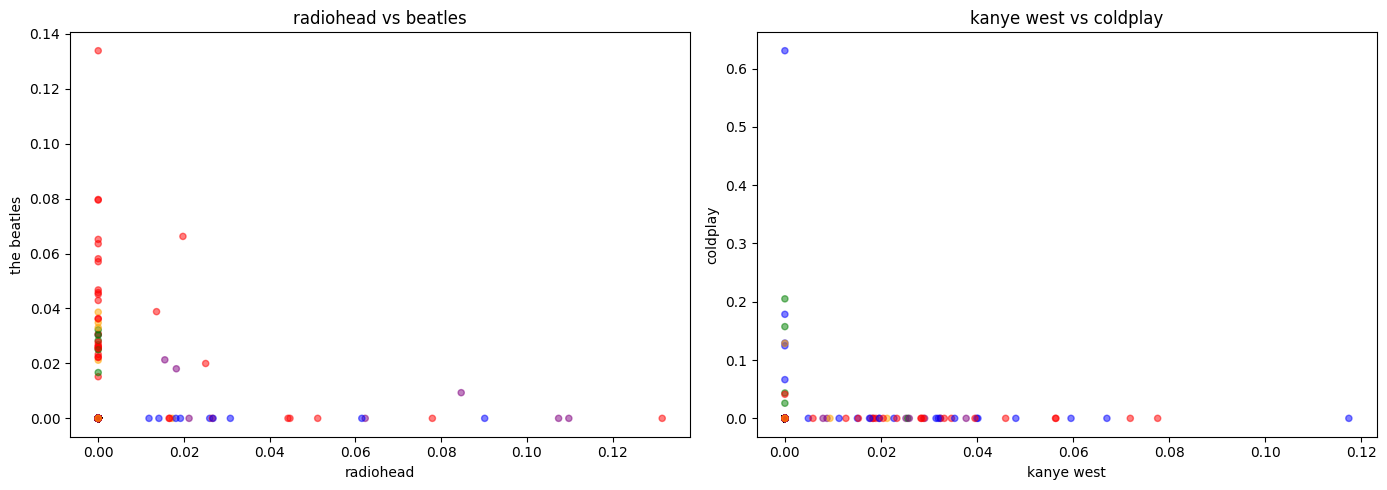

In [ ]:
import matplotlib.pyplot as plt

# -- YOUR CODE HERE --
colors = ['red', 'blue', 'green', 'orange', 'purple']
label_colors = [colors[l] for l in labels]

artist_names = list(ratings.index)
idx_radiohead = artist_names.index('radiohead')
idx_beatles   = artist_names.index('the beatles')
idx_coldplay  = artist_names.index('coldplay')
idx_kanye     = artist_names.index('kanye west')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(ratings_norm[:, idx_radiohead], ratings_norm[:, idx_beatles],
                c=label_colors, alpha=0.5, s=20)
axes[0].set_xlabel('radiohead')
axes[0].set_ylabel('the beatles')
axes[0].set_title('radiohead vs beatles')

axes[1].scatter(ratings_norm[:, idx_kanye], ratings_norm[:, idx_coldplay],
                c=label_colors, alpha=0.5, s=20)
axes[1].set_xlabel('kanye west')
axes[1].set_ylabel('coldplay')
axes[1].set_title('kanye west vs coldplay')

plt.tight_layout()
plt.show()

**Ответ:** Визуализации получились плохими, так как почти все точки сгруппированы у нуля. Причина в том, что данные очень разреженные

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

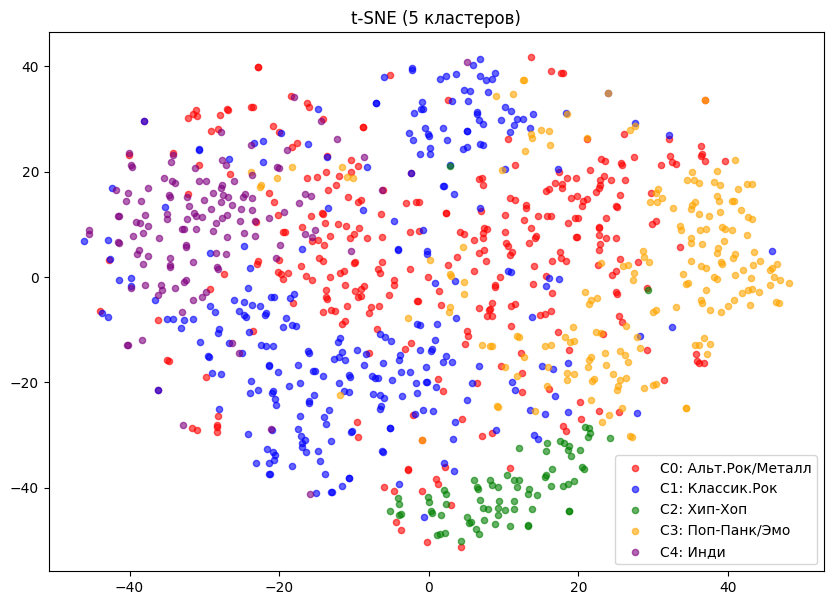

In [ ]:
from sklearn.manifold import TSNE

# -- YOUR CODE HERE --
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb = tsne.fit_transform(ratings_norm)

plt.figure(figsize=(10, 7))
cluster_names = ['Альт.Рок/Металл', 'Классик.Рок', 'Хип-Хоп', 'Поп-Панк/Эмо', 'Инди']
for c in range(5):
    mask = labels == c
    plt.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.6,
                color=colors[c], label=f'C{c}: {cluster_names[c]}')
plt.legend()
plt.title('t-SNE (5 кластеров)')
plt.show()

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

k=2, silhouette=0.0045
k=7, silhouette=0.0061
k=12, silhouette=0.0078
k=17, silhouette=0.0075
k=22, silhouette=0.0064
k=27, silhouette=0.0074
k=32, silhouette=0.0064
k=37, silhouette=0.0074
k=42, silhouette=0.0058
k=47, silhouette=0.0082
k=52, silhouette=0.0067
k=57, silhouette=0.0090
k=62, silhouette=0.0089
k=67, silhouette=0.0106
k=72, silhouette=0.0115
k=77, silhouette=0.0106
k=82, silhouette=0.0110
k=87, silhouette=0.0113
k=92, silhouette=0.0119
k=97, silhouette=0.0131

Лучшее k=97, Silhouette=0.0131


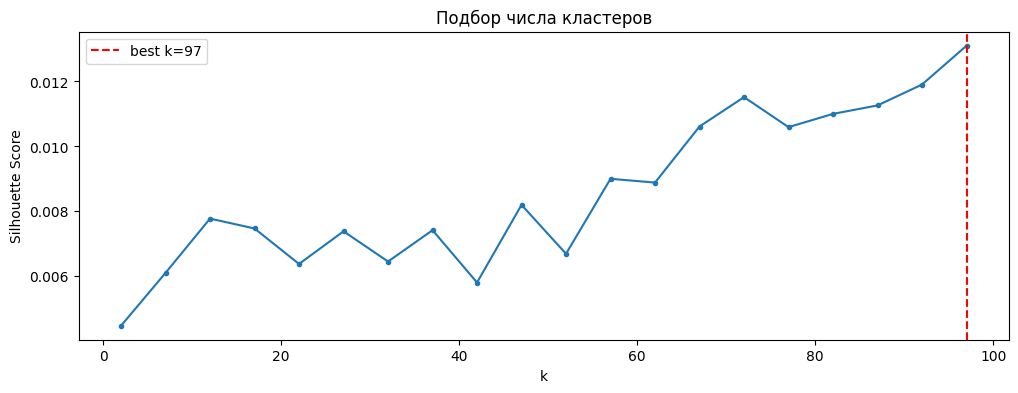

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
k_range = range(2, 101, 5)

for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=3, max_iter=100)
    lbl_k = km_k.fit_predict(ratings_norm)
    sil_scores.append(silhouette_score(ratings_norm, lbl_k))
    print(f"k={k}, silhouette={sil_scores[-1]:.4f}", flush=True)

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nЛучшее k={best_k}, Silhouette={max(sil_scores):.4f}")

plt.figure(figsize=(12, 4))
plt.plot(list(k_range), sil_scores, 'o-', markersize=3)
plt.axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Подбор числа кластеров')
plt.legend()
plt.show()

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = km.fit_predict(ratings_norm)
centroids = km.cluster_centers_

Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [ ]:
# -- YOUR CODE HERE --
for c in range(best_k):
    dists = [cosine(ratings_norm[i], centroids[c]) for i in range(len(ratings_norm))]
    top5 = [artist_names[i] for i in sorted(range(len(dists)), key=lambda x: dists[x])[:5]]
    print(f"Кластер {c}: {top5}")

Кластер 0: ['queens off the stone age', 'the hives', 'eagles of death metal', 'papa roach', 'all time low']
Кластер 1: ['m.i.a.', 'girl talk', 'santogold', 'eminem', 'lykke li']
Кластер 2: ['the shins', 'deathcab for cutie', 'spoon', 'the decemberists', 'modest mouse']
Кластер 3: ['white stripes', 'the raconteurs', 'the strokes', 'franz ferdinand', 'muse']
Кластер 4: ['beck', 'radiohead', 'eels', 'cake', 'soul coughing']
Кластер 5: ['de la soul', 'a tribe called quest', 'gangstarr', 'murs and 9th wonder', 'blackalicious']
Кластер 6: ['chris brown', 't-pain', 'usher', 'scott jill', 'erykah badu']
Кластер 7: ['newsboys', 'jars of clay', 'switchfoot', 'david crowder*band', 'michal w. smith']
Кластер 8: ['hellogoodbye', 'panic! at the disco -', 'my chemicall romance', 'motion city soundtrack', 'plain white t＇s']
Кластер 9: ['brand new', 'taking back sunday', 'saosin', 'say anything', 'jimmy eat world']
Кластер 10: ['depeche Мode', 'new order', 'the smiths', 'the cure', 'morrissey']
Кластер

**Ответ:** Смысл кластеров полностью сохранился, но стал детальнее. Например, если при k=5 был один большой кластер "Хип-Хоп", то теперь он разбился на несколько узких жанров

Сделайте t-SNE визуализацию полученной кластеризации.

C:\Users\Dasha\AppData\Local\Temp\ipykernel_49248\458226599.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', best_k)


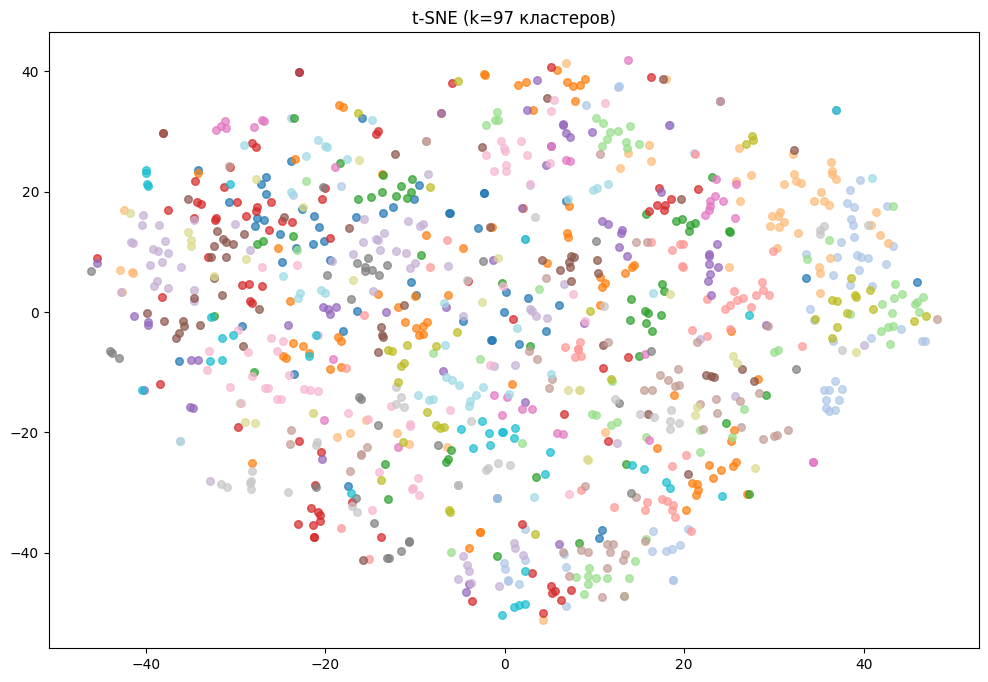

In [ ]:
# -- YOUR CODE HERE --
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb = tsne.fit_transform(ratings_norm)

plt.figure(figsize=(12, 8))
cmap = plt.cm.get_cmap('tab20', best_k)
for c in range(best_k):
    mask = labels == c
    plt.scatter(emb[mask, 0], emb[mask, 1], s=30, alpha=0.7, color=cmap(c))

plt.title(f't-SNE (k={best_k} кластеров)')
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

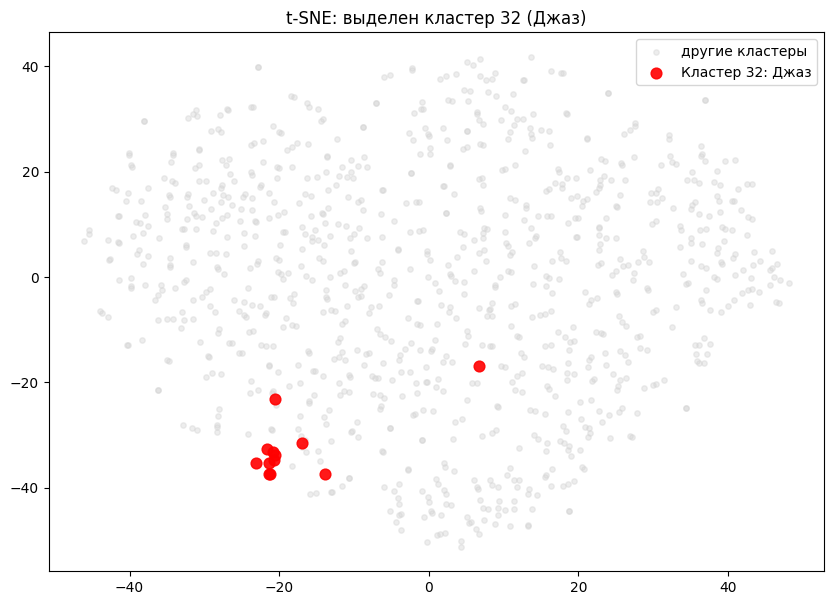

In [ ]:
# -- YOUR CODE HERE --
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb = tsne.fit_transform(ratings_norm)

jazz_cluster = 32
mask = labels == jazz_cluster

plt.figure(figsize=(10, 7))
plt.scatter(emb[~mask, 0], emb[~mask, 1],
            c='lightgray', s=15, alpha=0.4, label='другие кластеры')
plt.scatter(emb[mask, 0], emb[mask, 1],
            c='red', s=60, alpha=0.9, label=f'Кластер {jazz_cluster}: Джаз')
plt.legend()
plt.title(f't-SNE: выделен кластер {jazz_cluster} (Джаз)')
plt.show()

**Ответ:** Джазовый кластер хорошо отражается в визуализации — большинство красных точек образуют компактную плотную группу в левом нижнем углу, пространственно отделённую от остальных исполнителей. Это подтверждает, что аудитория джаза практически не пересекается с аудиторией других жанров.